# Exercises week 41

**October 5–9, 2026**

Date: **Deadline is Friday October 9 at midnight**

# Overarching aims of the exercises this week

This week you will implement the entire feed-forward pass of a neural
network. Next week you will compute the gradient of the network by
implementing backpropagation by hand, and by using JAX, which does the
backward pass for you (much easier!). Next week you will also use the
gradient to train the network with a gradient method. There is, however, an
optional exercise at the end of this set to get started on training the
network and getting good results already now.

We recommend that you do the exercises by editing and running this notebook,
as it includes some checks along the way that you have implemented the pieces
of the feed-forward pass correctly, and running small parts of the code at a
time is important for understanding the methods. If you cannot run the
notebook locally, Google Colab works as well, though we recommend that you set
up VSCode (or JupyterLab) and your Python environment to run code like this on
your own machine; ask on the course Discord or at the lab sessions if you
have trouble.

The Tuesday session does exactly the same steps on the digits data of
`scikit-learn` (`week41tuesday.ipynb`); here you do them on your own on the
iris data. Monday's lecture notebook (`week41.ipynb`) contains the complete
network, including the backward pass you will write next week.

First, here are the packages and the activation functions you are going to
need; don't change this cell. We use `jax.numpy` (imported as `jnp`) instead
of plain `numpy` inside the activation functions, so that in the last
exercise `jax.grad` can differentiate everything. `jnp` works on ordinary
`numpy` arrays and behaves like `numpy` for everything we do here.

In [791]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)   # 64-bit floats, so that results agree with numpy to ~1e-15
import jax.numpy as jnp                    # numpy-compatible functions that JAX can differentiate
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


# Defining some activation functions
def ReLU(z):
    return jnp.where(z > 0, z, 0.0)


def sigmoid(z):
    return 1 / (1 + jnp.exp(-z))


def softmax(z):
    """Compute softmax values for each set of scores in the rows of the matrix z.
    Used with batched input data: one row of scores per sample."""
    e_z = jnp.exp(z - jnp.max(z, axis=1, keepdims=True))
    return e_z / jnp.sum(e_z, axis=1, keepdims=True)


def softmax_vec(z):
    """Compute softmax values for each set of scores in the vector z.
    Use this function when you use the activation function on one vector at a time."""
    e_z = jnp.exp(z - jnp.max(z))
    return e_z / jnp.sum(e_z)

# Exercise 1

In this exercise you will compute the activation of the first layer. You only
need to change the code in the cells right below an exercise; the rest works
out of the box. Feel free to make changes and see how things work, though!

In [792]:
np.random.seed(2024)

x = np.random.randn(2)  # network input. This is a single input with two features
W1 = np.random.randn(4, 2)  # first layer weights

print("x:", x.shape)
print("W1:", W1.shape)

x: (2,)
W1: (4, 2)


**a)** Given the shape of the first-layer weight matrix, what is the input
shape of the neural network? What is the output shape of the first layer?

*Answer:* The input shape of the neural network is (2, ), in this case. The output shape of the first layer is (4, ) .

**b)** Define the bias of the first layer, `b1`, with the correct shape. (Run
the next cell right after the previous one, so that the random numbers line
up with the test solution below.)

In [793]:
b1 = np.random.randn(4)
print("b1:", b1.shape)


b1: (4,)


**c)** Compute the intermediary `z1` for the first layer.

In [794]:
z1 = W1 @ x + b1
print("z1:", z1.shape)
print(z1)

z1: (4,)
[ 0.60610368  4.0076268  -6.84805855  0.56469864]


**d)** Compute the activation `a1` for the first layer using the ReLU
activation function defined earlier.

In [795]:
a1 = ReLU(z1)
print("a1:", a1.shape)
print(a1)

a1: (4,)
[0.60610368 4.0076268  0.         0.56469864]


Confirm that you got the correct activation with the test below. Make sure
that you define `b1` with the `randn` function right after you define `W1`.

In [796]:
sol1 = np.array([0.60610368, 4.0076268, 0.0, 0.56469864])

print(np.allclose(a1, sol1))

True


# Exercise 2

Now we will add a layer to the network with an output of length 8 and ReLU
activation.

**a)** What is the input of the second layer? What is its shape?

*Answer:* The input of the second layer is the output of the first layer. Since we want an output of 8, and the input will be 4 (since that was the output of the first layer), the shape will be (8, 4).  

**b)** Define the weight and bias of the second layer with the right shapes.

In [797]:
W2 = np.random.randn(8, 4)  
b2 = np.random.randn(8)

**c)** Compute the intermediary `z2` and the activation `a2` for the second
layer.

In [798]:
z2 = W2 @ a1 + b2
a2 = ReLU(z2)

Confirm that you got the correct activation shape with the test below.

In [799]:
print(
    np.allclose(np.exp(len(a2)), 2980.9579870417283)
)  # This should evaluate to True if a2 has the correct shape :)

True


# Exercise 3

We often want our neural networks to have many layers of varying sizes. To
avoid writing very long and error-prone code where we explicitly define and
evaluate each layer, we should keep all our layers in a single variable which
is easy to create and use.

**a)** Complete the function below so that it returns a list `layers` of
weight and bias tuples `(W, b)` for each layer, in order, with the correct
shapes, that we can use later as our network parameters.

In [800]:
def create_layers(network_input_size, layer_output_sizes):
    layers = []

    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = np.random.randn(layer_output_size, i_size)
        b = np.random.randn(layer_output_size)
        layers.append((W, b))

        i_size = layer_output_size
    return layers

**b)** Complete the function below so that it evaluates the intermediary `z`
and the activation `a` for each layer, with ReLU activation, and returns the
final activation `a`. This is the complete feed-forward pass — a full neural
network!

In [801]:
def feed_forward_all_relu(layers, x):
    a = x
    for W, b in layers:
        z = W @ a + b
        a = ReLU(z)
    return a

**c)** Create a network with input size 8 and layers with output sizes 10, 16,
6, 2. Evaluate it and make sure that you get vectors of the correct size along
the way.

In [802]:
input_size = 8
layer_output_sizes = [10, 16, 6, 2]

x = np.random.rand(input_size)
layers = create_layers(input_size, layer_output_sizes)

for l, (W, b) in enumerate(layers):
    print(f"layer {l + 1}: W: {W.shape}, b: {b.shape}")

predict = feed_forward_all_relu(layers, x)
print(predict)

layer 1: W: (10, 8), b: (10,)
layer 2: W: (16, 10), b: (16,)
layer 3: W: (6, 16), b: (6,)
layer 4: W: (2, 6), b: (2,)
[5.36337158 0.        ]


**d)** Why is a neural network with no activation functions mathematically
equivalent to (can be reduced to) a neural network with only one layer?

*Answer:* If you have no activation function, you dont give the next layer anything to start with, so there will be no next layer produced.

# Exercise 4 - Custom activation for each layer

So far, every layer has used the same activation, ReLU. We often want to use
other types of activation, however, so we need to update our code to support
different activation functions in different layers. Make sure that you have
completed every previous exercise before trying this one.

**a)** Complete the `feed_forward` function, which accepts a list of
activation functions as an argument and evaluates these activation functions
at each layer.

In [803]:
def feed_forward(x, layers, activation_funcs):
    a = x
    for (W, b), activation_func in zip(layers, activation_funcs):
        z = W @ a + b
        a = activation_func(z)
    return a

**b)** You are now given a list with three activation functions, two ReLU
and one sigmoid. (Don't call them yet! You can make a list with function
names as elements, and then call these elements of the list later. If you add
other functions than the ones defined at the start of the notebook, make sure
everything inside them is written with `jnp`, like the functions above, since
we want to use automatic differentiation on all of them later.)

Evaluate a network with three layers and these activation functions. You can choose the relevant sizes.

In [804]:
network_input_size = 8
layer_output_sizes = [10, 16, 6]
activation_funcs = [ReLU, ReLU, sigmoid]
layers = create_layers(network_input_size, layer_output_sizes)

x = np.random.randn(network_input_size)
out = feed_forward(x, layers, activation_funcs)

print(out)

[0.05228192 1.         0.59999186 0.93457593 0.99786026 0.99999997]


**c)** How does the output of the network change if you use sigmoid in the
hidden layers and ReLU in the output layer?

*Answer:* First sigmoid will force the numbers to be between 0 and 1, and then the output with ReLU in the output layer, will have exactly zero values since the negative z will be set to zero. 


In [805]:
activation_funcs = [sigmoid, sigmoid, ReLU]
out = feed_forward(x, layers, activation_funcs)

print(out)



[0.         2.72771082 4.25366266 0.65139649 0.         0.98143355]


# Exercise 5 - Processing multiple inputs at once

So far, the feed-forward function has taken one input vector at a time. This
vector undergoes a linear transformation and then an element-wise non-linear
operation for each layer. Sending one vector in at a time is great for
understanding how the network transforms data with its linear and non-linear
operations, but not the best for numerical efficiency. Now we want to be able
to send many inputs through the network at once. This makes the code a bit
harder to understand, but it is faster and more compact, and it is the
convention used in the lecture notes (Eq. (8.21)) and in Monday's code. It
will be worth the trouble.

To process multiple inputs at once, while still performing the same
operations, you only need to flip a couple of things around.

**a)** Complete the function `create_layers_batch` so that the weight matrix
is the transpose of what it was when you only sent in one input at a time.

In [806]:
def create_layers_batch(network_input_size, layer_output_sizes):
    layers = []

    i_size = network_input_size
    for layer_output_size in layer_output_sizes:
        W = ...
        b = ...
        layers.append((W, b))

        i_size = layer_output_size
    return layers

**b)** Make a matrix of inputs with the shape (number of inputs, number of
features); you choose the number of inputs and the number of features per
input. Then complete the function `feed_forward_batch` so that you can process
this matrix of inputs with only one matrix multiplication and one broadcast
vector addition per layer. (Hint: you only need to swap two variables around
from your previous implementation, but remember to test that you get the same
results for equivalent inputs!)

In [807]:
inputs = np.random.rand(1000, 4)


def feed_forward_batch(inputs, layers, activation_funcs):
    a = inputs
    for (W, b), activation_func in zip(layers, activation_funcs):
        z = ...
        a = ...
    return a

**c)** Create and evaluate a neural network with 4 input features, and layers
with output sizes 12, 10, 3 and activations ReLU, ReLU, softmax.

In [808]:
network_input_size = ...
layer_output_sizes = [...]
activation_funcs = [...]
layers = create_layers_batch(network_input_size, layer_output_sizes)

feed_forward_batch(inputs, layers, activation_funcs)

Ellipsis

You should use this batched approach from now on, as it leads to much more
compact code. Remember, however, that each input is still treated separately,
and that you will need to keep the transposed weight matrix and other details
in mind when implementing backpropagation next week.

# Exercise 6 - Predicting on real data

You will now evaluate your neural network on the iris data set
(https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html).

This data set contains measurements of 150 flowers of three different species,
which can be separated quite well using the four features given for each
flower: the length and width of the sepals and of the petals. You will later
train your network to actually make good predictions.

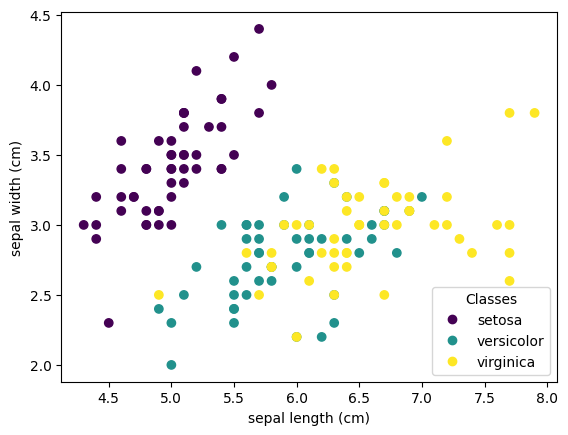

In [809]:
iris = datasets.load_iris()

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

In [810]:
inputs = iris.data

# Since each prediction is a vector with a score for each of the three species,
# we make each target a vector with a 1 for the correct species and a 0 for the others (one-hot).
targets = np.zeros((len(iris.data), 3))
for i, t in enumerate(iris.target):
    targets[i, t] = 1


def accuracy(predictions, targets):
    one_hot_predictions = np.zeros(predictions.shape)

    for i, prediction in enumerate(predictions):
        one_hot_predictions[i, np.argmax(prediction)] = 1
    return accuracy_score(one_hot_predictions, targets)

**a)** What should the input size of the network be with this data set? What
should the output size of the last layer be?

**b)** Create a network with two layers, the first with sigmoid activation and
the last with softmax. The first layer should have 8 "nodes", the second the
number of nodes you found in a). The softmax returns a "probability
distribution", in the sense that the numbers in the output are positive and
add up to 1, and their magnitudes reflect the magnitudes of the scores before
the softmax. Remember to use the batched versions of `create_layers` and
`feed_forward`.

In [811]:
...
layers = ...

**c)** Evaluate your model on the entire iris data set. For later purposes we
will split the data into training and test sets and compute gradients on
smaller batches of the training data; for now, evaluate the network on the
whole data set at once.

In [812]:
predictions = feed_forward_batch(inputs, layers, activation_funcs)

TypeError: 'ellipsis' object is not iterable

**d)** Compute the accuracy of your model using the `accuracy` function
defined above. Recreate your model a couple of times and see how the accuracy
changes. What accuracy would you expect from guessing?

In [ ]:
print(accuracy(predictions, targets))

# Exercise 7 - Training on real data (Optional)

To be able to do anything useful with your neural network, you need to train
it. For this we need a cost function and a way to take the gradient of the
cost function with respect to the network parameters. The following exercises
guide you through taking the gradient with JAX and updating the network
parameters with it. Feel free to implement gradient methods like Adam if you
finish everything.

Since we are doing a classification task with multiple output classes, we use
the multiclass cross-entropy cost function (Eq. (5.28) of the lecture notes),
which measures how much probability the network assigns to the correct class
of each sample.

In [ ]:
def cross_entropy(predict, target):
    return jnp.sum(-target * jnp.log(predict))


def cost(input, layers, activation_funcs, target):
    predict = feed_forward_batch(input, layers, activation_funcs)
    return cross_entropy(predict, target)

To improve our network on whatever prediction task we have given it, we need
to use a sensible cost function, take the gradient of that cost function with
respect to our network parameters, the weights and biases, and then update
the weights and biases using these gradients. To clarify, we need to find and
use

$$
\frac{\partial C}{\partial W}, \quad \frac{\partial C}{\partial b}
$$

for every layer.

Now we need to compute these gradients. Doing this by hand for a neural
network is the backpropagation algorithm of Monday's lecture, which you will
implement next week — but we can also let JAX do it for us, which is what one
does in practice. With the code cell below we create a function that returns
all of these gradients at once. `jax.grad(cost, argnums=1)` differentiates
`cost` with respect to its second argument, the list of layers, and returns a
list with the same structure: one `(dW, db)` pair per layer.

In [ ]:
gradient_func = jax.grad(
    cost, argnums=1
)  # Taking the gradient wrt. the second input to the cost function, i.e. the layers

**a)** What shape should the gradient of the cost function with respect to
the weights and biases of each layer have?

**b)** Use the `gradient_func` function to take the gradient of the cross
entropy with respect to the weights and biases of the network. Check the
shapes of what is inside. What does `jax.grad` actually do?

In [ ]:
layers_grad = gradient_func(
    inputs, layers, activation_funcs, targets
)  # Don't change this

**c)** Finish the `train_network` function. Note that the update builds a
new list of layers instead of changing the arrays in place: the gradients
returned by JAX are JAX arrays, and a new list is the cleanest way to combine
them with the old parameters. The learning rate is called `gamma`, as
everywhere else in the course.

In [ ]:
def train_network(
    inputs, layers, activation_funcs, targets, gamma=0.001, epochs=100
):
    for i in range(epochs):
        layers_grad = gradient_func(inputs, layers, activation_funcs, targets)
        layers = [(W - ..., b - ...) for (W, b), (W_g, b_g) in zip(layers, layers_grad)]
    return layers

**d)** What do we call the gradient method used above?

**e)** Train your network and see how the accuracy changes. Make a plot if
you want.

In [ ]:
...

**f)** How high an accuracy is it possible to achieve with a neural network
on this data set, if we use the whole data set as training data? Is that a
useful number?

## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 2; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| A layer has weight matrix `W` of shape (4, 2). What goes in, what comes out, and how many parameters does the layer have? | Input of length 2, output of length 4 (plus a bias of length 4): $4\cdot 2 + 4 = 12$ parameters; the shapes of $W$ and $b$ fix the architecture. |
| Why does a network without activation functions collapse to a single layer? | The composition of linear maps is linear: $W^3(W^2(W^1x + b^1) + b^2) + b^3 = \tilde W x + \tilde b$. The non-linearity between the layers is what buys anything beyond linear regression. |
| Why does a list of `(W, b)` tuples plus a loop beat writing `W1, b1, W2, b2, ...`? | The same code serves any depth and any widths; the architecture becomes data (`layer_output_sizes`), not code. |
| Why is a list of functions `[ReLU, ReLU, sigmoid]` passed, and not `[ReLU(z), ...]`? | Functions are values in Python; the forward pass calls the right one at each layer. The output activation is chosen by the range of the target (sigmoid for a probability, softmax for a distribution over classes, identity for a real number). |
| In the batched version `W` is the transpose of the single-vector version. Why? | With samples in rows, $z = x^T W$ for every row at once, i.e. $Z = XW + b$ (Eq. 8.21), the transpose of $z = W x + b$; mixing the two conventions is the most common source of shape errors. |
| The softmax function subtracts the maximum of each row before exponentiating. Why, and why `axis=1`? | Subtracting a constant leaves the softmax unchanged and keeps every exponent $\le 0$, so nothing overflows; `axis=1` is the row of scores of one sample. |
| An untrained network scores about 33% on the iris data. Why that number, and what does its output look like? | Three classes, random weights: the softmax is nearly flat and the predicted class hardly depends on the input, so the accuracy is that of guessing. |
| Why is the cross entropy $-\sum_k y_k \ln a_k$ the right cost for the softmax output? | With one-hot targets it is $-\ln a_{k^*}$, the negative log-probability of the correct class; paired with the softmax its output error is simply $a - y$ (Eq. 8.69). |
| What does `jax.grad(cost, argnums=1)` return, and what does it compute? | A list with the structure of `layers`, one `(dW, db)` per layer, obtained by reverse-mode automatic differentiation of the forward pass — the same numbers backpropagation gives, which you implement next week. |
| The training accuracy after many epochs on the whole iris set is close to 100%. Is that a good number? | No: it is a training-set accuracy, with no test set and no cross-validation it says nothing about generalisation (Section 3.14). |

### Practicalities

Deliver your solutions (a single Jupyter notebook) in Canvas before
**Friday October 9 at midnight**. Collaboration is encouraged — list your
collaborators. Next week's exercises implement the backward pass by hand for
this very network and compare it with `jax.grad`; Project 2, published after
the Project 1 deadline, builds on both.